# Análisis Exploratorio del Mercado Laboral Tech 🌎
## Stack Overflow Developer Survey 2024

**Objetivo:** Explorar el mercado laboral tecnológico a nivel global y en LATAM,
identificando roles más demandados, salarios, tecnologías y habilidades clave.

**Fuente de datos:** Stack Overflow Developer Survey 2024  
**Herramientas:** Python, Pandas, Matplotlib, Seaborn  
**Autor:** Juan José Vásquez Agudelo

In [42]:
#importación de librerías
import pandas as pd

#cargamos el archivo csv en un dataframe de pandas
df = pd.read_csv("survey_results_public.csv")

print(df.head(5)) #imprimir las primeras 5 columnas del dataframe

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())




   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

In [20]:
print(df.shape[0]) #imprime cuantas filas tiene el dataset
print("El porcentaje de nulos de la columna ConvertedCompYearly es:" + str(round(df["ConvertedCompYearly"].isnull().sum()/df.shape[0]*100,2))+ "%")



65437
El porcentaje de nulos de la columna ConvertedCompYearly es:64.19%


## Hallazgo 1
El 64% de los encuestados no reportó su salario anual (`ConvertedCompYearly`).
El análisis salarial se basará en el 36% restante (~23,000 respuestas).

In [26]:
df_clean = df[["MainBranch", "Age", "Employment", "RemoteWork", "EdLevel", "Country", "YearsCodePro", "DevType", "LanguageHaveWorkedWith", "ConvertedCompYearly"]]
print(df_clean.head())
print(df_clean.shape[1])

                       MainBranch                 Age           Employment  \
0  I am a developer by profession  Under 18 years old  Employed, full-time   
1  I am a developer by profession     35-44 years old  Employed, full-time   
2  I am a developer by profession     45-54 years old  Employed, full-time   
3           I am learning to code     18-24 years old   Student, full-time   
4  I am a developer by profession     18-24 years old   Student, full-time   

  RemoteWork                                            EdLevel  \
0     Remote                          Primary/elementary school   
1     Remote       Bachelor’s degree (B.A., B.S., B.Eng., etc.)   
2     Remote    Master’s degree (M.A., M.S., M.Eng., MBA, etc.)   
3        NaN  Some college/university study without earning ...   
4        NaN  Secondary school (e.g. American high school, G...   

                                             Country YearsCodePro  \
0                           United States of America       

## Selección de variables relevantes
Se seleccionaron 10 columnas de las 114 originales, 
enfocadas en perfil profesional, experiencia, rol, 
tecnologías y compensación.

In [34]:
print(df_clean.value_counts("DevType").head(10)) #imprimimos los 10 roles tech más comunes entre los encuestados
top10 = df_clean.value_counts("DevType").head(10)

DevType
Developer, full-stack                            18260
Developer, back-end                               9928
Student                                           5102
Developer, front-end                              3349
Developer, desktop or enterprise applications     2493
Other (please specify):                           2458
Developer, mobile                                 2021
Developer, embedded applications or devices       1623
Engineering manager                               1275
Academic researcher                               1238
Name: count, dtype: int64


## Hallazgo 2
Los roles más comunes son Full-stack (18,260) y Back-end (9,928).
Los estudiantes ocupan el tercer lugar con 5,102 respuestas.

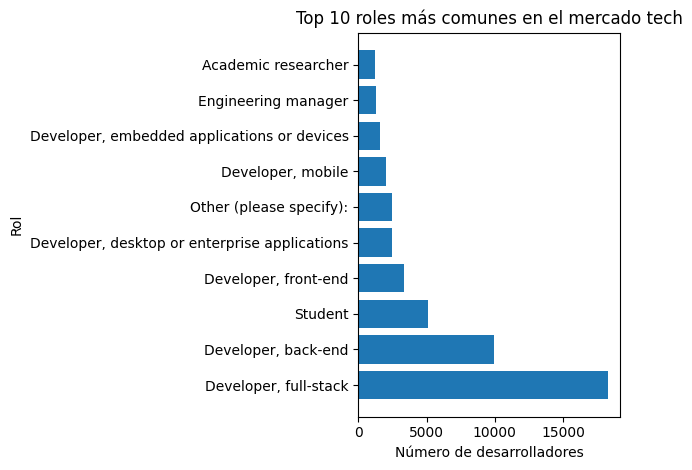

In [41]:
import matplotlib.pyplot as plt 
plt.barh(top10.index , top10.values)
plt.title("Top 10 roles más comunes en el mercado tech")
plt.xlabel("Número de desarrolladores")
plt.ylabel("Rol")
plt.tight_layout()
plt.show()


## Hallazgo 2 — Roles más comunes
Full-stack (18,260) y Back-end (9,928) dominan el mercado.
Los estudiantes ocupan el tercer lugar, lo que refleja 
una comunidad en crecimiento activo.